# Bates Grain Interface

Loading Bates Model and Scalers...
✅ Model and Scalers loaded successfully!


--- Enter the dimensions of the Bates Grain for prediction ---


c:\Users\Ctrl-Halim\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\base.py:442: InconsistentVersionWarning: Trying to unpickle estimator RobustScaler from version 1.6.1 when using version 1.7.2. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
c:\Users\Ctrl-Halim\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\base.py:442: InconsistentVersionWarning: Trying to unpickle estimator StandardScaler from version 1.6.1 when using version 1.7.2. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
C:\Users\Ctrl-Halim\AppData\Local\Temp\ipykernel_22532\3337551675.py:58: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead,


----------------------------------------
--- Predicted Performance Results ---
----------------------------------------
ISP: 173.56 s
Total Impulse (Calculated): 90741.71 N.s
Burn Time: 6.37 s
Max Thrust: 36268.68 N
----------------------------------------



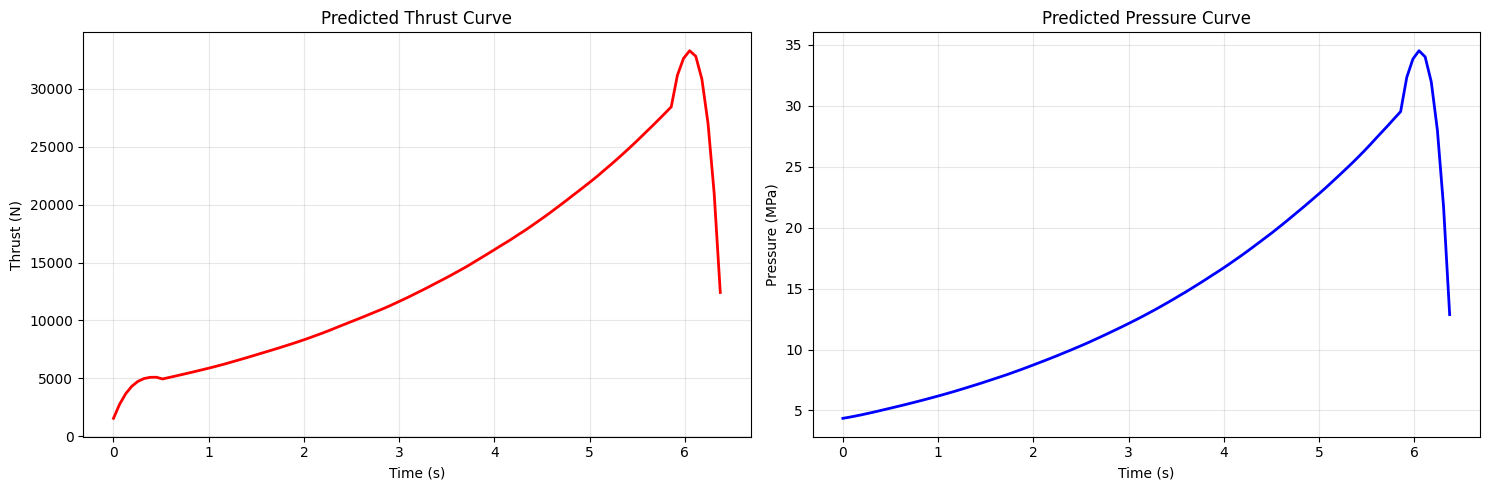

In [20]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import savgol_filter
import joblib
from tensorflow.keras.models import load_model

# ==========================================
# 1. Loading Model and Scalers
# ==========================================
print("Loading Bates Model and Scalers...")
try:
    # تحميل النموذج (بدون compile لتجنب أخطاء دوال الـ Loss)
    my_model = load_model('M:\\Graduation Project\\Team B\\Code_project\\test models\\Forward Models\\Bates Models\\Bates_model.keras', compile=False)
    
    # تحميل الـ 4 Scalers
    my_s_X = joblib.load('M:\\Graduation Project\\Team B\\Code_project\\test models\\Forward Models\\Bates Models\\scaler_X.pkl')
    my_s_yt = joblib.load('M:\\Graduation Project\\Team B\\Code_project\\test models\\Forward Models\\Bates Models\\scaler_thrust.pkl')
    my_s_yp = joblib.load('M:\\Graduation Project\\Team B\\Code_project\\test models\\Forward Models\\Bates Models\\scaler_pressure.pkl')
    my_s_ys = joblib.load('M:\\Graduation Project\\Team B\\Code_project\\test models\\Forward Models\\Bates Models\\scaler_scalars.pkl')
    
    print("✅ Model and Scalers loaded successfully!\n")
except Exception as e:
    print(f" Error loading files: {e}")
    raise e

# ==========================================
# 2. Prediction Function
# ==========================================
def get_user_input_and_predict_bates(model, s_X, s_yt, s_yp, s_ys):
    print("\n" + "="*50)
    print("--- Enter the dimensions of the Bates Grain for prediction ---")
    print("="*50)
    try:
        # 1. استلام المدخلات
        l_val = float(input("Length: "))
        d_val = float(input("Diameter: "))
        c_d_val = float(input("Core_Diameter: "))
        t_d_val = float(input("Throat_Diameter: "))
        e_d_val = float(input("Exit_Diameter: "))
        
        # Input arrangement (بنفس ترتيب التدريب)
        user_inputs = np.array([[l_val, d_val, c_d_val, t_d_val, e_d_val]])
        user_inputs_scaled = s_X.transform(user_inputs)
        
        # 2. Prediction
        preds = model.predict(user_inputs_scaled, verbose=0)
        
        # 3. فك تشفير النتائج (Inverse Transform)
        thrust_pred = s_yt.inverse_transform(preds[0])
        pressure_pred = s_yp.inverse_transform(preds[1])
        scalars_pred = s_ys.inverse_transform(preds[2])
        
        # Preparing the timeline
        burn_time = scalars_pred[0][2]
        time_steps = np.linspace(0, burn_time, 100)
        
        # Calculating the Impulse mathematically
        calculated_impulse = np.trapz(thrust_pred[0], time_steps)        
        
        print("\n" + "-"*40)
        print("--- Predicted Performance Results ---")
        print("-"*40)
        print(f"ISP: {scalars_pred[0][0]:.2f} s")
        print(f"Total Impulse (Calculated): {calculated_impulse:.2f} N.s")  
        print(f"Burn Time: {burn_time:.2f} s")
        print(f"Max Thrust: {scalars_pred[0][3]:.2f} N")
        print("-"*40 + "\n")
        
        # تنعيم المنحنيات باستخدام savgol_filter
        smoothed_pressure = savgol_filter(pressure_pred[0], window_length=15, polyorder=3)
        smoothed_thrust = savgol_filter(thrust_pred[0], window_length=15, polyorder=3)

        # رسم النتائج
        plt.figure(figsize=(15, 5))
        
        #   (Thrust Plot)
        plt.subplot(1, 2, 1)
        plt.plot(time_steps, smoothed_thrust, color='red', linewidth=2)
        plt.title('Predicted Thrust Curve')
        plt.xlabel('Time (s)')
        plt.ylabel('Thrust (N)')
        plt.grid(True, alpha=0.3)
        
        #   (Pressure Plot)  
        plt.subplot(1, 2, 2)
        plt.plot(time_steps, smoothed_pressure, color='blue', linewidth=2) 
        plt.title('Predicted Pressure Curve')
        plt.xlabel('Time (s)')
        plt.ylabel('Pressure (MPa)')
        plt.grid(True, alpha=0.3)
        
        plt.tight_layout()
        plt.show()
      
    except ValueError:
        print("\n[Error]: Please enter valid numeric values.")
    except Exception as e:
        print(f"\n[Error]: An unexpected error occurred: {e}")

# ==========================================
# 3. Execution
# ==========================================
if __name__ == "__main__":
    get_user_input_and_predict_bates(my_model, my_s_X, my_s_yt, my_s_yp, my_s_ys)

# D Grain Interface


--- Enter the dimensions of Grain D for prediction ---


c:\Users\Ctrl-Halim\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\base.py:442: InconsistentVersionWarning: Trying to unpickle estimator RobustScaler from version 1.6.1 when using version 1.7.2. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
c:\Users\Ctrl-Halim\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\base.py:442: InconsistentVersionWarning: Trying to unpickle estimator StandardScaler from version 1.6.1 when using version 1.7.2. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(



----------------------------------------
--- Predicted Performance Results (Grain D) ---
----------------------------------------
ISP: 176.90 s
Total Impulse (Model): 125030.73 N.s
Total Impulse (Calculated Area): 127103.95 N.s
Burn Time: 20.85 s
Max Thrust: 9699.02 N
----------------------------------------



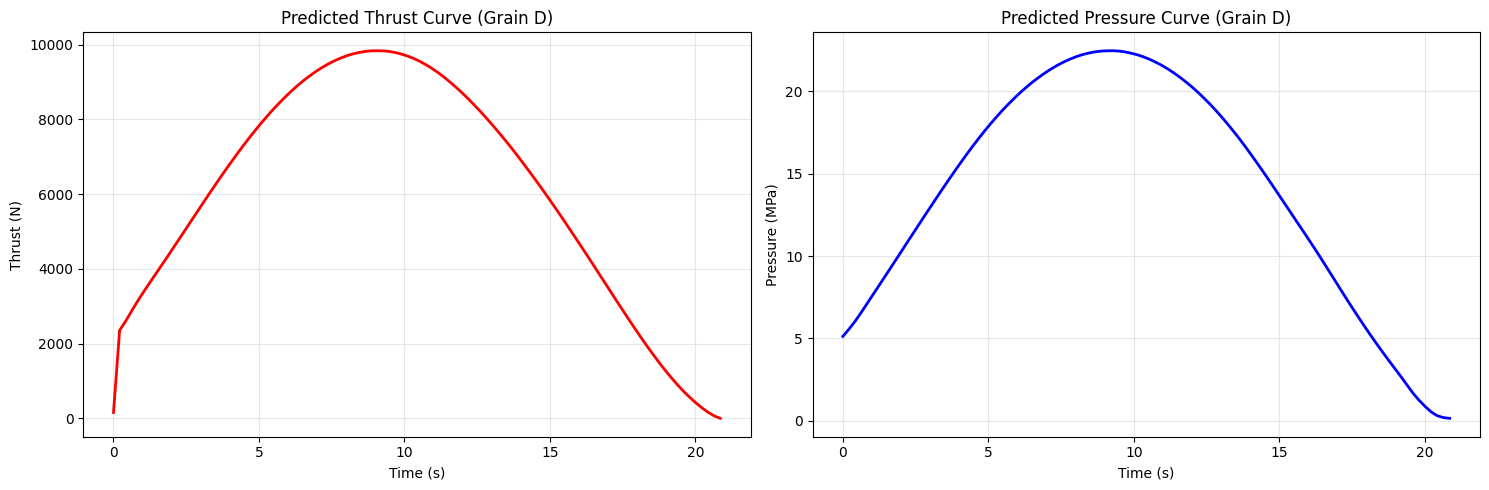

In [19]:
import pickle
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.models import load_model

def get_user_input_and_predict_grain_d():
    # ─── Load Model and Scalers inside the function to prevent NameError ───
    try:
        model = load_model('M:\\Graduation Project\\Team B\\Code_project\\test models\\Forward Models\\D Models\\grain_d_model.keras', compile=False)
        
        with open('M:\\Graduation Project\\Team B\\Code_project\\test models\\Forward Models\\D Models\\grain_d_scalers.pkl', 'rb') as f:
            scalers_dict = pickle.load(f)
            
        s_X = scalers_dict['s_X']
        s_yt = scalers_dict['s_yt']
        s_yp = scalers_dict['s_yp']
        s_ys = scalers_dict['s_ys']
    except FileNotFoundError:
        print("\n[Error]: Model or Scaler files not found in the current directory!")
        print("Please ensure 'grain_d_model.keras' and 'grain_d_scalers.pkl' are present.")
        return
    except Exception as e:
        print(f"\n[Error]: An error occurred while loading files: {e}")
        return

    # ─── User Interface and Inference ───
    print("\n" + "="*50)
    print("--- Enter the dimensions of Grain D for prediction ---")
    print("="*50)
    try:
        l_val = float(input("Length: "))
        d_val = float(input("Diameter: "))
        so_val = float(input("Slot Offset: "))
        t_d_val = float(input("Throat Diameter: "))
        e_d_val = float(input("Exit Diameter: "))
        
        # Format inputs to match the original training column order
        user_inputs = np.array([[l_val, d_val, so_val, t_d_val, e_d_val]])
        user_inputs_scaled = s_X.transform(user_inputs)
        
        # Model Prediction
        preds = model.predict(user_inputs_scaled, verbose=0)
        
        # Inverse Transform to original scales
        thrust_pred = s_yt.inverse_transform(preds[0])
        pressure_pred = s_yp.inverse_transform(preds[1])
        scalars_pred = s_ys.inverse_transform(preds[2])
        
        # Extract scalar values
        isp = scalars_pred[0][0]
        predicted_impulse = scalars_pred[0][1]
        burn_time = scalars_pred[0][2]
        max_thrust = scalars_pred[0][3]
        
        # Prepare the timeline
        time_steps = np.linspace(0, burn_time, 100)
        calculated_impulse = np.trapezoid(thrust_pred[0], time_steps)        
        
        print("\n" + "-"*40)
        print("--- Predicted Performance Results (Grain D) ---")
        print("-"*40)
        print(f"ISP: {isp:.2f} s")
        print(f"Total Impulse (Model): {predicted_impulse:.2f} N.s")
        print(f"Total Impulse (Calculated Area): {calculated_impulse:.2f} N.s")
        print(f"Burn Time: {burn_time:.2f} s")
        print(f"Max Thrust: {max_thrust:.2f} N")
        print("-"*40 + "\n")
        
        # Plotting curves (without smoothing filters to preserve raw physics)
        plt.figure(figsize=(15, 5))
        
        # Thrust Plot
        plt.subplot(1, 2, 1)
        plt.plot(time_steps, thrust_pred[0], color='red', linewidth=2)
        plt.title('Predicted Thrust Curve (Grain D)')
        plt.xlabel('Time (s)')
        plt.ylabel('Thrust (N)')
        plt.grid(True, alpha=0.3)
        
        # Pressure Plot
        plt.subplot(1, 2, 2)
        plt.plot(time_steps, pressure_pred[0], color='blue', linewidth=2) 
        plt.title('Predicted Pressure Curve (Grain D)')
        plt.xlabel('Time (s)')
        plt.ylabel('Pressure (MPa)')
        plt.grid(True, alpha=0.3)
        
        plt.tight_layout()
        plt.show()
      
    except ValueError:
        print("\n[Error]: Please enter valid numeric values.")
    except Exception as e:
        print(f"\n[Error]: An unexpected error occurred: {e}")

# Run the function
get_user_input_and_predict_grain_d()

# Moon Grain Interface


   Moon Grain - Performance Predictor (ReLU Edition)


c:\Users\Ctrl-Halim\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\base.py:442: InconsistentVersionWarning: Trying to unpickle estimator MinMaxScaler from version 1.6.1 when using version 1.7.2. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(



---------------------------------------------
   Predicted Performance (Moon Grain)
---------------------------------------------
   ISP                   : 178.06 s
   Burn Time             : 11.71 s
   Total Impulse         : 127440.15 N.s
   Max Thrust            : 20116.76 N
---------------------------------------------


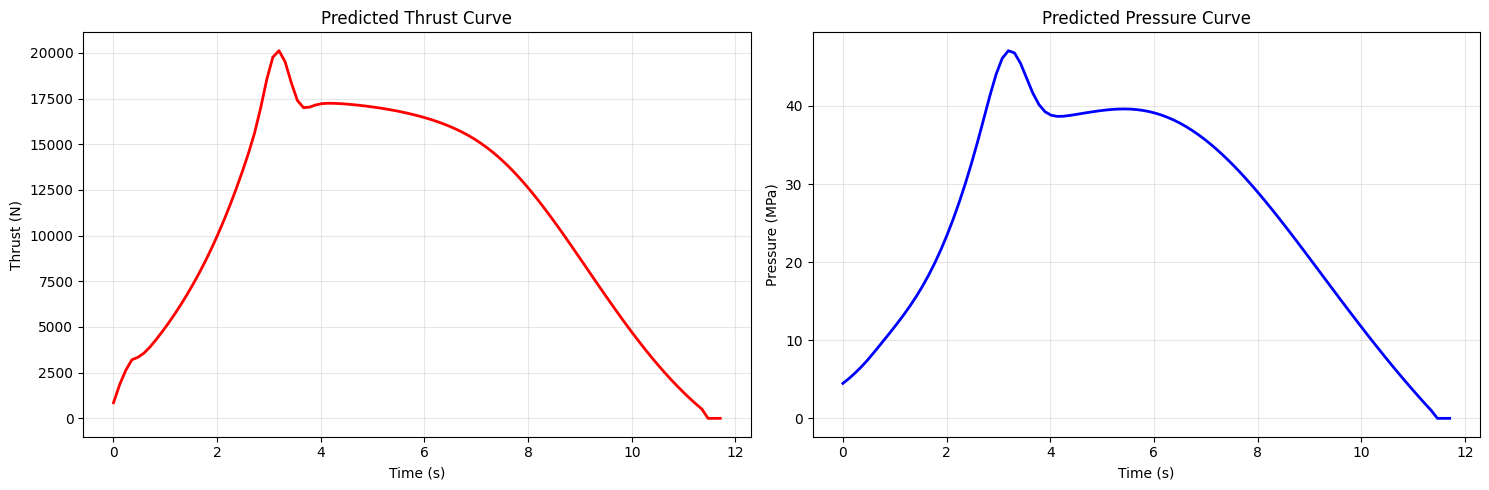

In [18]:
import joblib
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.models import load_model
from scipy.signal import savgol_filter

# ===================================================================
# Moon Grain - Performance Predictor (Forward Model Engine)
# ===================================================================
def get_user_input_and_predict_moon():
    print('\n' + '='*55)
    print('   Moon Grain - Performance Predictor (ReLU Edition)')
    print('='*55)
    
    # ─── 1. Load Model and Scalers Safely Inside to Prevent NameErrors ───
    try:
        # compile=False bypasses missing custom training loss/metrics functions
        moon_forward = load_model('M:\\Graduation Project\\Team B\\Code_project\\test models\\Forward Models\\Moon Models\\Moon_Forward_Model.keras', compile=False)
        
        # Load the saved configuration elements
        s_X  = joblib.load('Forward Models/Moon Models/moon_fwd_scaler_X.pkl')
        s_ys = joblib.load('Forward Models/Moon Models/moon_fwd_scaler_scalars.pkl')
        
        # Extract physical normalization dictionary max constraints
        max_vals = joblib.load('M:\\Graduation Project\\Team B\\Code_project\\test models\\Forward Models\\Moon Models\\moon_fwd_max_values.pkl')
        yt_max = max_vals['yt_max']
        yp_max = max_vals['yp_max']
        
    except FileNotFoundError as e:
        print(f"\n[Error]: Missing required deployment asset file. Please check paths.\nDetails: {e}")
        return
    except Exception as e:
        print(f"\n[Error]: An unexpected runtime loading error occurred: {e}")
        return

    # ─── 2. Handle Dimensional User Inputs ───
    try:
        l_val  = float(input('Length (cm):               '))
        od_val = float(input('Outer Diameter (cm):       '))
        id_val = float(input('Inner Diameter/Core (cm):  '))
        co_val = float(input('Core Offset (cm):          ')) 
        td_val = float(input('Throat Diameter (cm):      '))
        ed_val = float(input('Exit Diameter (cm):        '))

        # Prepare structural input matrix boundary shape
        user_inputs        = np.array([[l_val, od_val, id_val, co_val, td_val, ed_val]])
        user_inputs_scaled = s_X.transform(user_inputs)

        # Execute Forward Network Call
        preds = moon_forward.predict(user_inputs_scaled, verbose=0)

        # ─── 3. Rescale Output Performance Horizons ───
        # De-normalize profile shapes via absolute max weights
        thrust_pred   = preds[0][0] * yt_max
        pressure_pred = preds[1][0] * yp_max
        
        # De-normalize constant metrics via Scikit-Learn standard scalar
        scalars_pred  = s_ys.inverse_transform(preds[2])[0]
        isp           = max(scalars_pred[0], 1e-9)
        burn_time     = max(scalars_pred[2], 1e-9)

        time_steps = np.linspace(0, burn_time, 100)

        # ─── 4. Preprocessing and Tail Conditioning ───
        # Apply Savitzky-Golay filtering safely clipped below zero
        smoothed_thrust   = np.clip(savgol_filter(thrust_pred, window_length=7, polyorder=2), 0, None)
        smoothed_pressure = np.clip(savgol_filter(pressure_pred, window_length=7, polyorder=2), 0, None)

        # Close out tail anomalies past structural regression limits
        peak_idx = np.argmax(smoothed_thrust)
        tail     = smoothed_thrust[peak_idx:]
        cutoff   = np.argmax(tail < 0.02 * smoothed_thrust.max())
        if cutoff > 0:
            smoothed_thrust[peak_idx + cutoff:] = 0
            smoothed_pressure[peak_idx + cutoff:] = 0

        # Calculate integration area under the finalized conditioned curves
        calculated_impulse = np.trapezoid(smoothed_thrust, time_steps)
        final_max_thrust = np.max(smoothed_thrust)

        # ─── 5. Print Results Table ───
        print('\n' + '-'*45)
        print('   Predicted Performance (Moon Grain)')
        print('-'*45)
        print(f'   ISP                   : {isp:.2f} s')
        print(f'   Burn Time             : {burn_time:.2f} s')
        print(f'   Total Impulse         : {calculated_impulse:.2f} N.s')
        print(f'   Max Thrust            : {final_max_thrust:.2f} N')
        print('-'*45)

        # ─── 6. Visualization Profiles Plot ───
        fig, axes = plt.subplots(1, 2, figsize=(15, 5))

        # Subplot 1: Rescaled Thrust Curve
        axes[0].plot(time_steps, smoothed_thrust, color='red', linewidth=2)
        axes[0].set_title('Predicted Thrust Curve')
        axes[0].set_xlabel('Time (s)')
        axes[0].set_ylabel('Thrust (N)')
        axes[0].grid(True, alpha=0.3)

        # Subplot 2: Rescaled Chamber Pressure Curve
        axes[1].plot(time_steps, smoothed_pressure, color='blue', linewidth=2)
        axes[1].set_title('Predicted Pressure Curve')
        axes[1].set_xlabel('Time (s)')
        axes[1].set_ylabel('Pressure (MPa)')
        axes[1].grid(True, alpha=0.3)

        plt.tight_layout()
        plt.show()

    except ValueError:
        print('\n[Error]: Please enter valid numeric values.')
    except Exception as e:
        print(f'\n[Error]: {e}')

# Run the function
get_user_input_and_predict_moon()

# Road and Tube Grain Interface

✅ Model loaded successfully from M:\Graduation Project\Team B\Code_project\test models\Forward Models\Road and Tube\rocket_motor_golden_rod_improved_fixed.keras
✅ scaler_X loaded successfully from M:\Graduation Project\Team B\Code_project\test models\Forward Models\Road and Tube\scaler_X (1).pkl
✅ scaler_t loaded successfully from M:\Graduation Project\Team B\Code_project\test models\Forward Models\Road and Tube\scaler_t (1).pkl
✅ scaler_p loaded successfully from M:\Graduation Project\Team B\Code_project\test models\Forward Models\Road and Tube\scaler_p (1).pkl
✅ scaler_Ys loaded successfully from M:\Graduation Project\Team B\Code_project\test models\Forward Models\Road and Tube\scaler_Ys (1).pkl

All files loaded. You can now use the 'loaded_model', 'loaded_scaler_X', 'loaded_scaler_t', 'loaded_scaler_p', and 'loaded_scaler_Ys' objects.

Please enter the dimensions for your rocket 1.3motor (numerical values expected):



c:\Users\Ctrl-Halim\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\base.py:442: InconsistentVersionWarning: Trying to unpickle estimator StandardScaler from version 1.6.1 when using version 1.7.2. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(



Simulating motor with your design...
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 763ms/step
====== Predicted Motor Performance ======
ISP:            174.49 s
Total Impulse:  91748.95 Ns
Burn Time:      7.59 s
Max Thrust:     34171.05 N


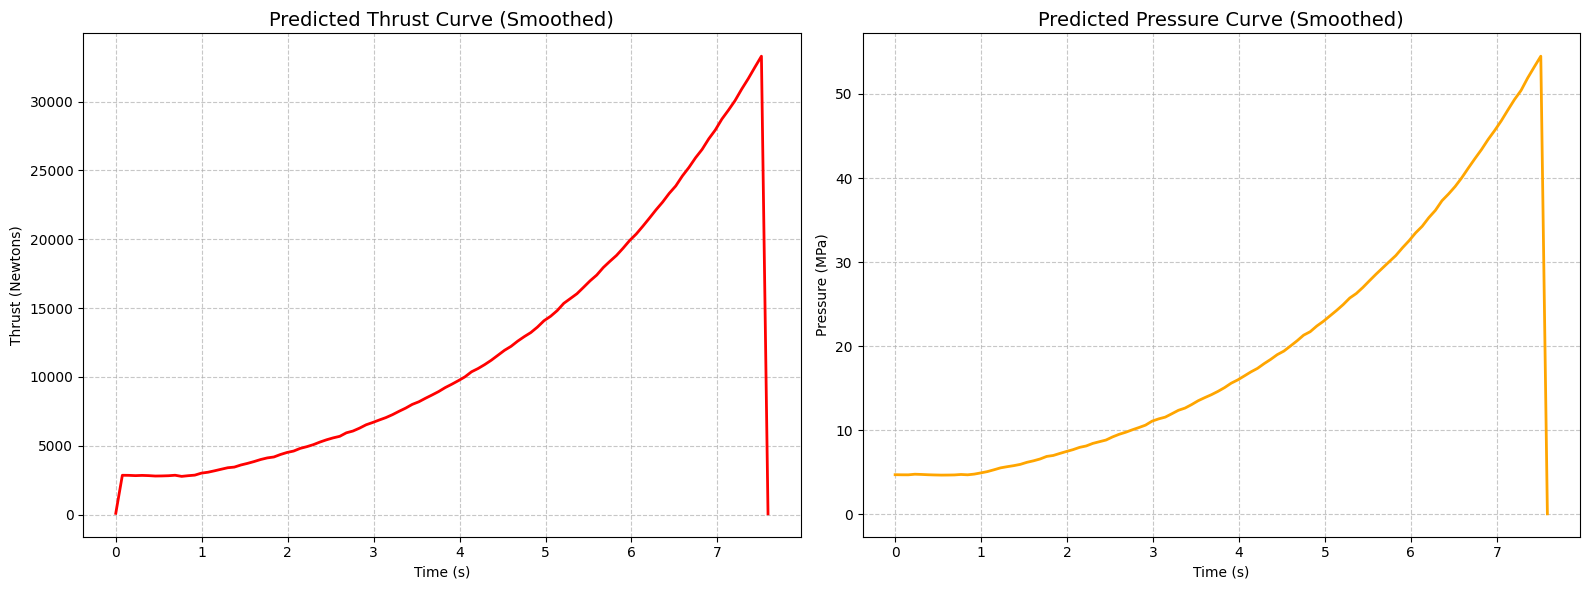


✅ Simulation completed successfully!


In [1]:
import os
import joblib
from tensorflow.keras.models import load_model
#from tensorflow.keras.utils import get_file
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import savgol_filter # Import savgol_filter

def simulate_new_motor(model, scaler_x, scaler_y, scaler_t, scaler_p, custom_features):
    """
    custom_features: list of 7 dimensions
    ['Length', 'Diameter', 'Core_Diameter', 'Rod_Diameter', 'Support_Diameter', 'Throat_Diameter', 'Exit_Diameter']
    """
    # 1. Feature Engineering
    throat_dia = custom_features[5]
    exit_dia = custom_features[6]

    throat_area = np.pi * (throat_dia / 2)**2
    exit_area = np.pi * (exit_dia / 2)**2

    # 2. Prepare Input array (9 features)
    input_array = np.array(custom_features + [throat_area, exit_area]).reshape(1, -1)

    # 3. Scale Input
    input_scaled = scaler_x.transform(input_array)

    # 4. Predict
    preds = model.predict(input_scaled)

    # 5. Decode Predictions
    raw_thrust_curve = scaler_t.inverse_transform(preds[0]).flatten()
    raw_pressure_curve = scaler_p.inverse_transform(preds[1]).flatten()

    scalars = scaler_y.inverse_transform(preds[2])[0]

    burn_time = scalars[2]
    time_axis = np.linspace(0, burn_time, 100)

    # 6. Apply smoothing for better visualization
    thrust_curve = np.maximum(0, savgol_filter(raw_thrust_curve, 3, 2))
    pressure_curve = np.maximum(0, savgol_filter(raw_pressure_curve, 3, 2))

    # 7. Print Metrics
    print("====== Predicted Motor Performance ======")
    print(f"ISP:            {scalars[0]:.2f} s")
    print(f"Total Impulse:  {scalars[1]:.2f} Ns")
    print(f"Burn Time:      {burn_time:.2f} s")
    print(f"Max Thrust:     {scalars[3]:.2f} N")
    print("=========================================")

    # 8. Plot Prediction
    plt.figure(figsize=(16, 6))

    plt.subplot(1, 2, 1)
    plt.plot(time_axis, thrust_curve, 'r-', linewidth=2)
    plt.title('Predicted Thrust Curve (Smoothed)', fontsize=14)
    plt.xlabel('Time (s)')
    plt.ylabel('Thrust (Newtons)')
    plt.grid(True, linestyle='--', alpha=0.7)

    plt.subplot(1, 2, 2)
    plt.plot(time_axis, pressure_curve, 'orange', linewidth=2)
    plt.title('Predicted Pressure Curve (Smoothed)', fontsize=14)
    plt.xlabel('Time (s)')
    plt.ylabel('Pressure (MPa)')
    plt.grid(True, linestyle='--', alpha=0.7)

    plt.tight_layout()
    plt.show()



# --- Define your model and scaler paths/URLs here ---
# If a path starts with 'http' or 'https', the file will be downloaded.
# Otherwise, it will be treated as a local file path.
model_path = 'M:\\Graduation Project\\Team B\\Code_project\\test models\\Forward Models\\Road and Tube\\rocket_motor_golden_rod_improved_fixed.keras'
scaler_X_path = 'M:\\Graduation Project\\Team B\\Code_project\\test models\\Forward Models\\Road and Tube\\scaler_X (1).pkl'
scaler_t_path = 'M:\\Graduation Project\\Team B\\Code_project\\test models\\Forward Models\\Road and Tube\\scaler_t (1).pkl'
scaler_p_path = 'M:\\Graduation Project\\Team B\\Code_project\\test models\\Forward Models\\Road and Tube\\scaler_p (1).pkl'
scaler_Ys_path = 'M:\\Graduation Project\\Team B\\Code_project\\test models\\Forward Models\\Road and Tube\\scaler_Ys (1).pkl'

def get_local_path(resource_path):
    if resource_path.startswith('http://') or resource_path.startswith('https://'):
        print(f"Downloading {resource_path}...")
        try:
            local_path = get_file(os.path.basename(resource_path), resource_path)
            print(f"Downloaded to {local_path}")
            return local_path
        except Exception as e:
            print(f"❌ Failed to download from {resource_path}: {e}")
            return None
    return resource_path

# Get local paths (download if URLs are provided)
model_path = get_local_path(model_path)
scaler_X_path = get_local_path(scaler_X_path)
scaler_t_path = get_local_path(scaler_t_path)
scaler_p_path = get_local_path(scaler_p_path)
scaler_Ys_path = get_local_path(scaler_Ys_path)

# --- Load Model and Scalers ---
loaded_model = None
loaded_scaler_X = None
loaded_scaler_t = None
loaded_scaler_p = None
loaded_scaler_Ys = None

try:
    # Load Model
    if model_path and os.path.exists(model_path):
        loaded_model = load_model(model_path)
        print(f"✅ Model loaded successfully from {model_path}")
    else:
        print(f"❌ Model file not found or could not be downloaded at {model_path}")

    # Load Scaler_X
    if scaler_X_path and os.path.exists(scaler_X_path):
        loaded_scaler_X = joblib.load(scaler_X_path)
        print(f"✅ scaler_X loaded successfully from {scaler_X_path}")
    else:
        print(f"❌ scaler_X file not found or could not be downloaded at {scaler_X_path}")

    # Load Scaler_t
    if scaler_t_path and os.path.exists(scaler_t_path):
        loaded_scaler_t = joblib.load(scaler_t_path)
        print(f"✅ scaler_t loaded successfully from {scaler_t_path}")
    else:
        print(f"❌ scaler_t file not found or could not be downloaded at {scaler_t_path}")

    # Load Scaler_p
    if scaler_p_path and os.path.exists(scaler_p_path):
        loaded_scaler_p = joblib.load(scaler_p_path)
        print(f"✅ scaler_p loaded successfully from {scaler_p_path}")
    else:
        print(f"❌ scaler_p file not found or could not be downloaded at {scaler_p_path}")

    # Load Scaler_Ys
    if scaler_Ys_path and os.path.exists(scaler_Ys_path):
        loaded_scaler_Ys = joblib.load(scaler_Ys_path)
        print(f"✅ scaler_Ys loaded successfully from {scaler_Ys_path}")
    else:
        print(f"❌ scaler_Ys file not found or could not be downloaded at {scaler_Ys_path}")

    if all([loaded_model, loaded_scaler_X, loaded_scaler_t, loaded_scaler_p, loaded_scaler_Ys]):
        print("\nAll files loaded. You can now use the 'loaded_model', 'loaded_scaler_X', 'loaded_scaler_t', 'loaded_scaler_p', and 'loaded_scaler_Ys' objects.")
    else:
        print("\nSome files could not be loaded. Please check the paths/URLs and try again.")

except Exception as e:
    print(f"An error occurred during loading: {e}")


import numpy as np

print("\nPlease enter the dimensions for your rocket 1.3motor (numerical values expected):\n")

# Get user inputs for the 7 dimensions
try:
    length = float(input("Enter Length (e.g., 130.0): "))
    diameter = float(input("Enter Diameter (e.g., 20.0): "))
    core_diameter = float(input("Enter Core Diameter (e.g., 4.0): "))
    rod_diameter = float(input("Enter Rod Diameter (e.g., 1.0): "))
    support_diameter = float(input("Enter Support Diameter (e.g., 0.0): "))
    throat_diameter = float(input("Enter Throat Diameter (e.g., 2.9): "))
    exit_diameter = float(input("Enter Exit Diameter (e.g., 4.35): "))

    custom_design_inputs = [
        length, diameter, core_diameter, rod_diameter,
        support_diameter, throat_diameter, exit_diameter
    ]

    print("\nSimulating motor with your design...")
    # Call the simulate_new_motor function with the global loaded model and scalers
    simulate_new_motor(
        loaded_model,
        loaded_scaler_X,
        loaded_scaler_Ys,
        loaded_scaler_t,
        loaded_scaler_p,
        custom_design_inputs
    )
    print("\n✅ Simulation completed successfully!")

except ValueError:
    print("❌ Invalid input. Please ensure all dimensions are entered as numbers.")
except NameError:
    print("❌ Error: 'loaded_model' or scalers not found. Please ensure the model and scalers are loaded first.")
except Exception as e:
    print(f"❌ An unexpected error occurred: {e}")

In [3]:
import zipfile
import json
import shutil
import tempfile
import os

old_model = r"M:\\Graduation Project\\Team B\\Code_project\\test models\\Forward Models\\Road and Tube\\rocket_motor_golden_rod_improved.keras"
new_model = r"M:\\Graduation Project\\Team B\\Code_project\\test models\\Forward Models\\Road and Tube\\rocket_motor_golden_rod_improved_fixed.keras"

tmp_dir = tempfile.mkdtemp()

# فك الملف
with zipfile.ZipFile(old_model, "r") as z:
    z.extractall(tmp_dir)

config_path = os.path.join(tmp_dir, "config.json")

# تحميل config
with open(config_path, "r", encoding="utf-8") as f:
    config = json.load(f)

# حذف quantization_config من أي مستوى
def remove_quantization(obj):
    if isinstance(obj, dict):
        obj.pop("quantization_config", None)
        for v in obj.values():
            remove_quantization(v)

    elif isinstance(obj, list):
        for item in obj:
            remove_quantization(item)

remove_quantization(config)

# حفظ config الجديد
with open(config_path, "w", encoding="utf-8") as f:
    json.dump(config, f)

# إعادة ضغط الملف
with zipfile.ZipFile(new_model, "w", zipfile.ZIP_DEFLATED) as z:
    for root, dirs, files in os.walk(tmp_dir):
        for file in files:
            full_path = os.path.join(root, file)
            rel_path = os.path.relpath(full_path, tmp_dir)
            z.write(full_path, rel_path)

print("DONE")
print(new_model)

DONE
M:\\Graduation Project\\Team B\\Code_project\\test models\\Forward Models\\Road and Tube\\rocket_motor_golden_rod_improved_fixed.keras


# Star Grain Interface


   Star Grain Motor — AI Performance Prediction


c:\Users\Ctrl-Halim\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\base.py:442: InconsistentVersionWarning: Trying to unpickle estimator RobustScaler from version 1.6.1 when using version 1.7.2. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
c:\Users\Ctrl-Halim\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\base.py:442: InconsistentVersionWarning: Trying to unpickle estimator StandardScaler from version 1.6.1 when using version 1.7.2. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(



---------------------------------------------
   Predicted Performance Results
---------------------------------------------
   ISP:              173.59 s
   Total Impulse:    8309.09 Ns
   Burn Time:        4.03 s
   Max Thrust:       4128.03 N
---------------------------------------------



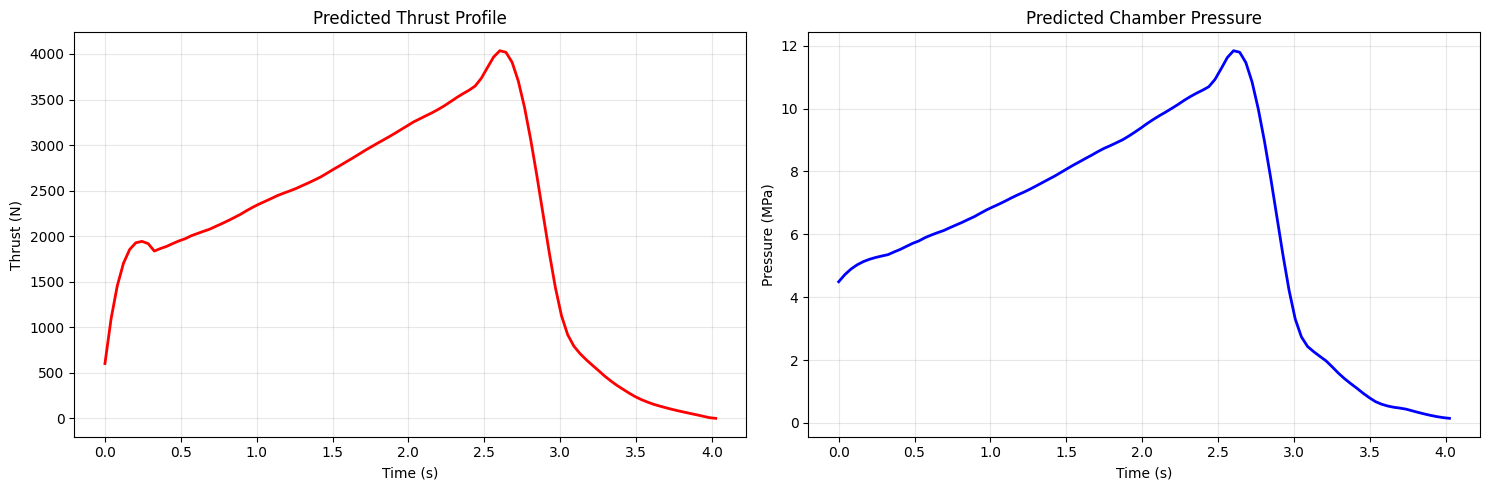

In [17]:
import os
import joblib
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.models import load_model
from scipy.signal import savgol_filter

# ===================================================================
# Star Grain Motor — AI Performance Prediction (Forward Engine)
# ===================================================================
def predict_star_grain():
    """
    Inputs (all in cm):
      Length, Outer Diameter, Number of Points,
      Point Length, Point Base Width, Throat Diameter, Exit Diameter
    Outputs:
      Thrust profile (N) + Pressure profile (MPa)
      ISP (s), Total Impulse (Ns), Burn Time (s), Max Thrust (N)
    """
    print('\n' + '='*55)
    print('   Star Grain Motor — AI Performance Prediction')
    print('='*55)
    
    # ─── 1. Load Model and Scalers Safely Inside to Prevent NameErrors ───
    try:
        # compile=False bypasses custom loss function compilation flags during inference
        model = load_model('M:\\Graduation Project\\Team B\\Code_project\\test models\\Forward Models\\Star Model\\Star_model.keras', compile=False)
        
        # Load the saved Scikit-Learn scalers
        s_X  = joblib.load('M:\\Graduation Project\\Team B\\Code_project\\test models\\Forward Models\\Star Model\\scaler_X.pkl')
        s_yt = joblib.load('M:\\Graduation Project\\Team B\\Code_project\\test models\\Forward Models\\Star Model\\scaler_thrust.pkl')
        s_yp = joblib.load('M:\\Graduation Project\\Team B\\Code_project\\test models\\Forward Models\\Star Model\\scaler_pressure.pkl')
        s_ys = joblib.load('M:\\Graduation Project\\Team B\\Code_project\\test models\\Forward Models\\Star Model\\scaler_scalars.pkl')
        
    except FileNotFoundError as e:
        print(f"\n[Error]: Missing required deployment asset files. Please check paths.\nDetails: {e}")
        return
    except Exception as e:
        print(f"\n[Error]: An unexpected model loading error occurred: {e}")
        return

    # ─── 2. Handle Dimensional User Inputs ───
    try:
        length    = float(input('Length (cm):              '))
        diameter  = float(input('Outer Diameter (cm):      '))
        n_points  = float(input('Number of Points (3/5/7/9): '))
        pt_length = float(input('Point Length (cm):        '))
        pt_width  = float(input('Point Base Width (cm):    '))
        throat    = float(input('Throat Diameter (cm):     '))
        exit_d    = float(input('Exit Diameter (cm):       '))

        # Prepare structural input matrix boundary shape
        user_in = np.array([[length, diameter, n_points, pt_length, pt_width, throat, exit_d]])
        user_sc = s_X.transform(user_in)
        
        # Execute Forward Network Predictions
        preds = model.predict(user_sc, verbose=0)

        # ─── 3. Rescale Output Performance Profiles ───
        thrust_pred   = s_yt.inverse_transform(preds[0])[0]
        pressure_pred = s_yp.inverse_transform(preds[1])[0]
        scalars_pred  = s_ys.inverse_transform(preds[2])[0]

        burn_time  = max(scalars_pred[2], 1e-9)
        time_steps = np.linspace(0, burn_time, 100)
        
        # Calculate integration area under the curve (Handles both trapz and trapezoid)
        if hasattr(np, 'trapezoid'):
            impulse = np.trapezoid(thrust_pred, time_steps)
        else:
            impulse = np.trapz(thrust_pred, time_steps)

        # Preprocessing: Savitzky-Golay Smoothing for Plotting
        thrust_smooth   = np.clip(savgol_filter(thrust_pred,   window_length=15, polyorder=3), 0, None)
        pressure_smooth = np.clip(savgol_filter(pressure_pred, window_length=15, polyorder=3), 0, None)

        # ─── 4. Print Performance Metrics Summary ───
        print('\n' + '-'*45)
        print('   Predicted Performance Results')
        print('-'*45)
        print(f'   ISP:              {scalars_pred[0]:.2f} s')
        print(f'   Total Impulse:    {impulse:.2f} Ns')
        print(f'   Burn Time:        {burn_time:.2f} s')
        print(f'   Max Thrust:       {scalars_pred[3]:.2f} N')
        print('-'*45 + '\n')

        # ─── 5. Visualization Profiles Plot ───
        plt.figure(figsize=(15, 5))

        # Subplot 1: Thrust Profile Curve
        plt.subplot(1, 2, 1)
        plt.plot(time_steps, thrust_smooth, color='red', linewidth=2)
        plt.title('Predicted Thrust Profile')
        plt.xlabel('Time (s)')
        plt.ylabel('Thrust (N)')
        plt.grid(True, alpha=0.3)

        # Subplot 2: Chamber Pressure Profile Curve
        plt.subplot(1, 2, 2)
        plt.plot(time_steps, pressure_smooth, color='blue', linewidth=2)
        plt.title('Predicted Chamber Pressure')
        plt.xlabel('Time (s)')
        plt.ylabel('Pressure (MPa)')
        plt.grid(True, alpha=0.3)

        plt.tight_layout()
        plt.show()

    except ValueError:
        print('\n[Error]: Please enter valid numeric values.')
    except Exception as e:
        print(f'\n[Error]: An unexpected prediction error occurred: {e}')

# Execute the engine
predict_star_grain()

# X Grain Interface

In [6]:
import zipfile
import json
import shutil
import tempfile
import os

old_model = r"M:\\Graduation Project\\Team B\\Code_project\\test models\\Forward Models\\X Models\\rocket_motor_golden_X (1).keras"
new_model = r"M:\\Graduation Project\\Team B\\Code_project\\test models\\Forward Models\\X Models\\rocket_motor_X_fixed.keras"

tmp_dir = tempfile.mkdtemp()

# فك الملف
with zipfile.ZipFile(old_model, "r") as z:
    z.extractall(tmp_dir)

config_path = os.path.join(tmp_dir, "config.json")

# تحميل config
with open(config_path, "r", encoding="utf-8") as f:
    config = json.load(f)

# حذف quantization_config من أي مستوى
def remove_quantization(obj):
    if isinstance(obj, dict):
        obj.pop("quantization_config", None)
        for v in obj.values():
            remove_quantization(v)

    elif isinstance(obj, list):
        for item in obj:
            remove_quantization(item)

remove_quantization(config)

# حفظ config الجديد
with open(config_path, "w", encoding="utf-8") as f:
    json.dump(config, f)

# إعادة ضغط الملف
with zipfile.ZipFile(new_model, "w", zipfile.ZIP_DEFLATED) as z:
    for root, dirs, files in os.walk(tmp_dir):
        for file in files:
            full_path = os.path.join(root, file)
            rel_path = os.path.relpath(full_path, tmp_dir)
            z.write(full_path, rel_path)

print("DONE")
print(new_model)

DONE
M:\\Graduation Project\\Team B\\Code_project\\test models\\Forward Models\\X Models\\rocket_motor_X_fixed.keras


✅ Model loaded successfully from M:\\Graduation Project\\Team B\\Code_project\\test models\\Forward Models\\X Models\\rocket_motor_X_fixed.keras
✅ scaler_X loaded successfully from M:\\Graduation Project\\Team B\\Code_project\\test models\\Forward Models\\X Models\\scaler_X (1).pkl
✅ scaler_ys loaded successfully from M:\\Graduation Project\\Team B\\Code_project\\test models\\Forward Models\\X Models\\scaler_ys (1).pkl
✅ Constants loaded successfully from M:\\Graduation Project\\Team B\\Code_project\\test models\\Forward Models\\X Models\\constants.pkl

✅ All necessary files loaded successfully! You can now use the model.

Please enter the dimensions for your rocket motor (numerical values expected):



c:\Users\Ctrl-Halim\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\base.py:442: InconsistentVersionWarning: Trying to unpickle estimator RobustScaler from version 1.6.1 when using version 1.7.2. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
c:\Users\Ctrl-Halim\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\base.py:442: InconsistentVersionWarning: Trying to unpickle estimator StandardScaler from version 1.6.1 when using version 1.7.2. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(



Simulating motor with your design...


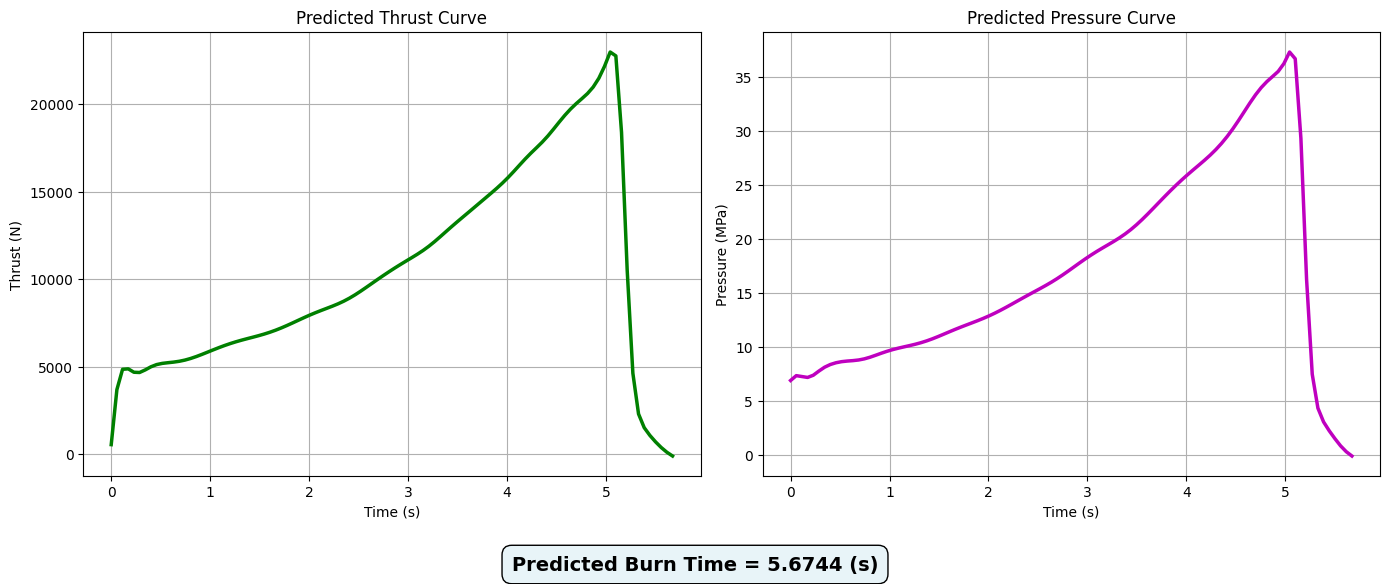


--- Predicted Performance Metrics ---
ISP (s)                  : 177.7525
Total Impulse (Ns)       : 58986.1289
Burn Time (s)            : 5.6744
Max Thrust (N)           : 22950.0547
Peak Pressure (MPa)      : 37.4691

✅ Simulation completed successfully!


In [8]:
import os
import joblib
import tensorflow as tf
from tensorflow.keras.models import load_model

# 1. Define the Custom Loss Function (Crucial for loading the model)
def shape_matching_loss(y_true, y_pred):
    y_true = tf.cast(y_true, tf.float32)
    y_pred = tf.cast(y_pred, tf.float32)

    # Standard Mean Squared Error
    mse = tf.reduce_mean(tf.square(y_true - y_pred), axis=-1)

    # Shape penalty (differences between consecutive points)
    diff_true = y_true[:, 1:] - y_true[:, :-1]
    diff_pred = y_pred[:, 1:] - y_pred[:, :-1]
    shape_penalty = tf.reduce_mean(tf.square(diff_true - diff_pred), axis=-1)

    return mse + 0.5 * shape_penalty

# --- Define your model and scaler paths (updated for Colab environment) ---
model_path = r"M:\\Graduation Project\\Team B\\Code_project\\test models\\Forward Models\\X Models\\rocket_motor_X_fixed.keras"
scaler_X_path = r"M:\\Graduation Project\\Team B\\Code_project\\test models\\Forward Models\\X Models\\scaler_X (1).pkl"
scaler_ys_path = r"M:\\Graduation Project\\Team B\\Code_project\\test models\\Forward Models\\X Models\\scaler_ys (1).pkl"
constants_path = r"M:\\Graduation Project\\Team B\\Code_project\\test models\\Forward Models\\X Models\\constants.pkl"

# --- Load Model and Scalers ---
loaded_model = None
loaded_scaler_X = None
loaded_scaler_ys = None
max_thrust_global = None
max_pressure_global = None
CURVE_POINTS = None

try:
    # Load Model
    if os.path.exists(model_path):
        loaded_model = load_model(
            model_path,
            custom_objects={'shape_matching_loss': shape_matching_loss}
        )
        print(f"✅ Model loaded successfully from {model_path}")
    else:
        print(f"❌ Model file not found at {model_path}")

    # Load Scaler_X
    if os.path.exists(scaler_X_path):
        loaded_scaler_X = joblib.load(scaler_X_path)
        print(f"✅ scaler_X loaded successfully from {scaler_X_path}")
    else:
        print(f"❌ scaler_X file not found at {scaler_X_path}")

    # Load Scaler_ys
    if os.path.exists(scaler_ys_path):
        loaded_scaler_ys = joblib.load(scaler_ys_path)
        print(f"✅ scaler_ys loaded successfully from {scaler_ys_path}")
    else:
        print(f"❌ scaler_ys file not found at {scaler_ys_path}")

    # Load Constants
    if os.path.exists(constants_path):
        constants = joblib.load(constants_path)
        max_thrust_global = constants['max_thrust_global']
        max_pressure_global = constants['max_pressure_global']
        CURVE_POINTS = constants['CURVE_POINTS']
        print(f"✅ Constants loaded successfully from {constants_path}")
    else:
        print(f"❌ Constants file not found at {constants_path}")

    if all([loaded_model, loaded_scaler_X, loaded_scaler_ys, max_thrust_global, max_pressure_global, CURVE_POINTS]):
        print("\n✅ All necessary files loaded successfully! You can now use the model.")
    else:
        print("\n⚠️ Some necessary files could not be loaded. Please check the paths and try again.")

except Exception as e:
    print(f"An error occurred during loading: {e}")


import numpy as np
import matplotlib.pyplot as plt # Needed for plotting

# Verify that all necessary variables are loaded
if not all([loaded_model, loaded_scaler_X, loaded_scaler_ys, max_thrust_global, max_pressure_global, CURVE_POINTS]):
    print("❌ Error: Required variables are not loaded. Please run the previous cell to load the model and constants.")
else:
    def simulate_new_motor(
        model,
        scaler_X_obj, # The scaler for input features
        scaler_ys_obj, # The scaler for scalar outputs
        length_val, diameter_val, slot_length_val, slot_width_val, throat_diameter_val, exit_diameter_val
    ):
        """
        Simulates a new rocket motor design based on the 6 input features the model was trained on.
        """
        # Create the input array for the model based on the 6 expected features
        model_input_features = np.array([[
            length_val, diameter_val, slot_length_val, slot_width_val, throat_diameter_val, exit_diameter_val
        ]])

        # Scale the input features using the loaded scaler
        custom_input_scaled = scaler_X_obj.transform(model_input_features)

        # Make predictions using the loaded model
        pred_thrust_scaled, pred_pressure_scaled, pred_scalars_scaled = model.predict(custom_input_scaled, verbose=0)

        # Inverse transform to get true physical units
        pred_thrust = pred_thrust_scaled[0] * max_thrust_global
        pred_pressure = pred_pressure_scaled[0] * max_pressure_global
        pred_scalars = scaler_ys_obj.inverse_transform(pred_scalars_scaled)[0]

        # Extract predicted Burn Time and create the time axis
        burn_time_val = pred_scalars[2]
        time_axis = np.linspace(0, burn_time_val, CURVE_POINTS)

        # Plot the curves
        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

        ax1.plot(time_axis, pred_thrust, 'g-', linewidth=2.5)
        ax1.set_title("Predicted Thrust Curve")
        ax1.set_xlabel("Time (s)")
        ax1.set_ylabel("Thrust (N)")
        ax1.grid(True)

        ax2.plot(time_axis, pred_pressure, 'm-', linewidth=2.5)
        ax2.set_title("Predicted Pressure Curve")
        ax2.set_xlabel("Time (s)")
        ax2.set_ylabel("Pressure (MPa)")
        ax2.grid(True)

        plt.tight_layout(rect=[0, 0.1, 1, 1])
        fig.text(0.5, 0.05, f"Predicted Burn Time = {burn_time_val:.4f} (s)",
                 ha='center', va='center', fontsize=14, fontweight='bold',
                 bbox=dict(boxstyle="round,pad=0.5", facecolor="#e8f4f8", edgecolor="black"))
        plt.show()

        # Print all static performance metrics
        scalar_names = ['ISP (s)', 'Total Impulse (Ns)', 'Burn Time (s)', 'Max Thrust (N)', 'Peak Pressure (MPa)']
        print("\n--- Predicted Performance Metrics ---")
        for i, name in enumerate(scalar_names):
            print(f"{name:<25}: {pred_scalars[i]:.4f}")

    print("\nPlease enter the dimensions for your rocket motor (numerical values expected):\n")

    # Get user inputs for the 6 dimensions
    try:
        length = float(input("Enter Length (e.g., 130.0): "))
        diameter = float(input("Enter Diameter (e.g., 20.0): "))
        slot_length = float(input("Enter Slot Length (e.g., 2.4): "))
        slot_width = float(input("Enter Slot Width (e.g., 2.5): "))
        throat_diameter = float(input("Enter Throat Diameter (e.g., 3.3): "))
        exit_diameter = float(input("Enter Exit Diameter (e.g., 4.95): "))

        # Call the new simulate_new_motor function with the collected inputs
        print("\nSimulating motor with your design...")
        simulate_new_motor(
            loaded_model,
            loaded_scaler_X,
            loaded_scaler_ys,
            length, diameter, slot_length, slot_width, throat_diameter, exit_diameter
        )
        print("\n✅ Simulation completed successfully!")

    except ValueError:
        print("❌ Invalid input. Please ensure all dimensions are entered as numbers.")
    except NameError as e:
        print(f"❌ Error: {e}")
        print("❌ Please ensure the model and scalers are loaded first by running the previous cell.")
    except Exception as e:
        print(f"❌ An unexpected error occurred: {e}")

# C Grain Interface

c:\Users\Ctrl-Halim\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\base.py:442: InconsistentVersionWarning: Trying to unpickle estimator MinMaxScaler from version 1.6.1 when using version 1.7.2. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(



   Co Grain - Performance Predictor (ReLU Edition)
Raw Curve Impulse : 116954.39 N.s

---------------------------------------------
   Predicted Performance (Co Grain)
---------------------------------------------
  ISP                    : 169.42 s
  Burn Time              : 27.92 s
  Max Thrust             : 5134.57 N
  Total Impulse          : 116954.39 N.s
---------------------------------------------


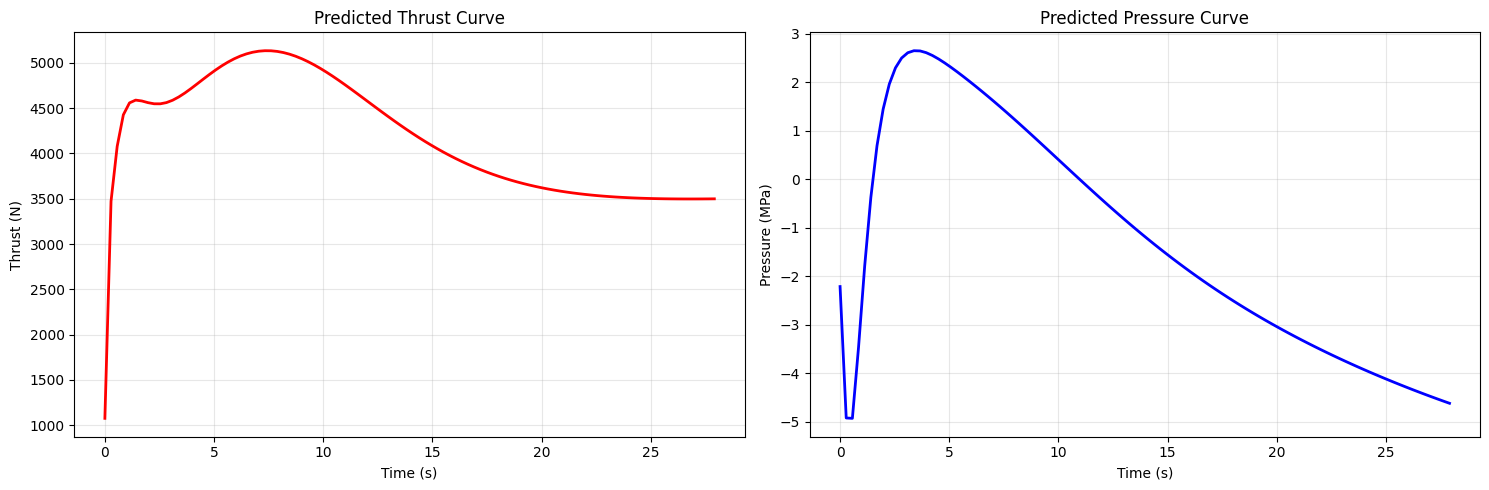


Please enter the dimensions for your rocket motor (numerical values expected):


Simulating motor with your design...


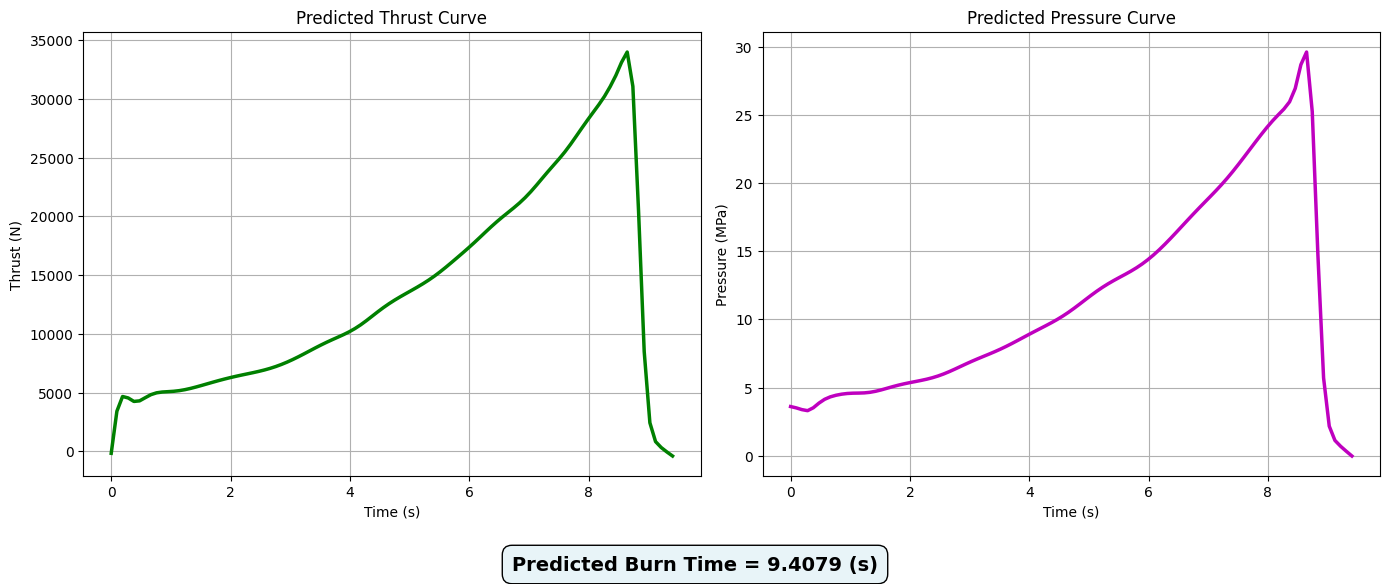


--- Predicted Performance Metrics ---
ISP (s)                  : 177.4192
Total Impulse (Ns)       : 125534.2109
Burn Time (s)            : 9.4079
Max Thrust (N)           : 34650.4258
Peak Pressure (MPa)      : 29.6501

✅ Simulation completed successfully!


In [10]:
import pandas as pd
import numpy as np
import joblib
import tensorflow as tf
import os
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d
from scipy.integrate import trapezoid

MODEL_PATH = r"M:\\Graduation Project\\Team B\\Code_project\\test models\\Forward Models\\C Models\\Co_Forward_Model.keras"

SCALAR_SCALER_PATH = r"M:\\Graduation Project\\Team B\\Code_project\\test models\\Forward Models\\C Models\\co_fwd_scaler_scalars.pkl"

Value_SCALER_PATH = r"M:\\Graduation Project\\Team B\\Code_project\\test models\\Forward Models\\C Models\\co_fwd_max_values.pkl"
SCALAR_X_PATH  = r"M:\\Graduation Project\\Team B\\Code_project\\test models\\Forward Models\\C Models\\co_fwd_scaler_X.pkl"

s_X = joblib.load(SCALAR_X_PATH)
s_ys = joblib.load(SCALAR_SCALER_PATH)
c_forward = tf.keras.models.load_model(MODEL_PATH)
def get_user_input_and_predict_c():
    print('\n' + '='*55)
    print('   Co Grain - Performance Predictor (ReLU Edition)')
    print('='*55)
    try:
        l_val  = float(input('Length (cm):               '))
        od_val = float(input('Diameter (cm):             '))
        id_val = float(input('Slot_Width (cm):           '))
        co_val = float(input('Slot_Offest (cm):          ')) 
        td_val = float(input('Throat Diameter (cm):      '))
        ed_val = float(input('Exit Diameter (cm):        '))

        user_inputs        = np.array([[l_val, od_val, id_val, co_val, td_val, ed_val]])
        user_inputs_scaled = s_X.transform(user_inputs)

        preds = c_forward.predict(user_inputs_scaled, verbose=0)

        max_vals = joblib.load(Value_SCALER_PATH)
        yt_max = max_vals['yt_max']
        yp_max = max_vals['yp_max']

        # استخراج المنحنيات
        thrust_pred   = preds[0][0] * yt_max
        pressure_pred = preds[1][0] * yp_max
        
        # استخراج القيم الثابتة
        scalars_pred  = s_ys.inverse_transform(preds[2])[0]

        isp       = max(scalars_pred[0], 1e-9)
        burn_time = max(scalars_pred[1], 1e-9)

        time_steps = np.linspace(0, burn_time, 100)
        
        raw_impulse = np.trapezoid(thrust_pred, time_steps)

        print(f'Raw Curve Impulse : {raw_impulse:.2f} N.s')

        # تنعيم خفيف للمنحنى بدون التأثير على القمة
        #smoothed_thrust   = np.clip(savgol_filter(thrust_pred, window_length=7, polyorder=2), 0, None)
        #smoothed_pressure = np.clip(savgol_filter(pressure_pred, window_length=7, polyorder=2), 0, None)
        smoothed_thrust   = thrust_pred.copy()
        smoothed_pressure = pressure_pred.copy()

        # إغلاق ذيل المنحنى
        # peak_idx = np.argmax(smoothed_thrust)
        # tail     = smoothed_thrust[peak_idx:]
        # cutoff   = np.argmax(tail < 0.02 * smoothed_thrust.max())
        # if cutoff > 0:
        #     smoothed_thrust[peak_idx + cutoff:] = 0
        #     smoothed_pressure[peak_idx + cutoff:] = 0

        # حساب المساحة من المنحنى النهائي
        #predicted_impulse = scalars_pred[1]
        final_max_thrust = np.max(thrust_pred)
        calculated_impulse = np.trapezoid(thrust_pred, time_steps)

        print('\n' + '-'*45)
        print('   Predicted Performance (Co Grain)')
        print('-'*45)
        print(f'  ISP                    : {isp:.2f} s')
        print(f'  Burn Time              : {burn_time:.2f} s')
        
        print(f'  Max Thrust             : {final_max_thrust:.2f} N')
        print(f'  Total Impulse          : {calculated_impulse:.2f} N.s')
        print('-'*45)

        fig, axes = plt.subplots(1, 2, figsize=(15, 5))

        axes[0].plot(time_steps, smoothed_thrust, color='red', linewidth=2)
        axes[0].set_title('Predicted Thrust Curve')
        axes[0].set_xlabel('Time (s)'); axes[0].set_ylabel('Thrust (N)')
        axes[0].grid(True, alpha=0.3)

        axes[1].plot(time_steps, smoothed_pressure, color='blue', linewidth=2)
        axes[1].set_title('Predicted Pressure Curve')
        axes[1].set_xlabel('Time (s)'); axes[1].set_ylabel('Pressure (MPa)')
        axes[1].grid(True, alpha=0.3)

        plt.tight_layout()
        plt.show()

    except ValueError:
        print('\n[Error]: Please enter valid numeric values.')
    except Exception as e:
        print(f'\n[Error]: {e}')

get_user_input_and_predict_c()

import numpy as np
import matplotlib.pyplot as plt # Needed for plotting

# Verify that all necessary variables are loaded
if not all([loaded_model, loaded_scaler_X, loaded_scaler_ys, max_thrust_global, max_pressure_global, CURVE_POINTS]):
    print("❌ Error: Required variables are not loaded. Please run the previous cell to load the model and constants.")
else:
    def simulate_new_motor(
        model,
        scaler_X_obj, # The scaler for input features
        scaler_ys_obj, # The scaler for scalar outputs
        length_val, diameter_val, slot_length_val, slot_width_val, throat_diameter_val, exit_diameter_val
    ):
        """
        Simulates a new rocket motor design based on the 6 input features the model was trained on.
        """
        # Create the input array for the model based on the 6 expected features
        model_input_features = np.array([[
            length_val, diameter_val, slot_length_val, slot_width_val, throat_diameter_val, exit_diameter_val
        ]])

        # Scale the input features using the loaded scaler
        custom_input_scaled = scaler_X_obj.transform(model_input_features)

        # Make predictions using the loaded model
        pred_thrust_scaled, pred_pressure_scaled, pred_scalars_scaled = model.predict(custom_input_scaled, verbose=0)

        # Inverse transform to get true physical units
        pred_thrust = pred_thrust_scaled[0] * max_thrust_global
        pred_pressure = pred_pressure_scaled[0] * max_pressure_global
        pred_scalars = scaler_ys_obj.inverse_transform(pred_scalars_scaled)[0]

        # Extract predicted Burn Time and create the time axis
        burn_time_val = pred_scalars[2]
        time_axis = np.linspace(0, burn_time_val, CURVE_POINTS)

        # Plot the curves
        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

        ax1.plot(time_axis, pred_thrust, 'g-', linewidth=2.5)
        ax1.set_title("Predicted Thrust Curve")
        ax1.set_xlabel("Time (s)")
        ax1.set_ylabel("Thrust (N)")
        ax1.grid(True)

        ax2.plot(time_axis, pred_pressure, 'm-', linewidth=2.5)
        ax2.set_title("Predicted Pressure Curve")
        ax2.set_xlabel("Time (s)")
        ax2.set_ylabel("Pressure (MPa)")
        ax2.grid(True)

        plt.tight_layout(rect=[0, 0.1, 1, 1])
        fig.text(0.5, 0.05, f"Predicted Burn Time = {burn_time_val:.4f} (s)",
                 ha='center', va='center', fontsize=14, fontweight='bold',
                 bbox=dict(boxstyle="round,pad=0.5", facecolor="#e8f4f8", edgecolor="black"))
        plt.show()

        # Print all static performance metrics
        scalar_names = ['ISP (s)', 'Total Impulse (Ns)', 'Burn Time (s)', 'Max Thrust (N)', 'Peak Pressure (MPa)']
        print("\n--- Predicted Performance Metrics ---")
        for i, name in enumerate(scalar_names):
            print(f"{name:<25}: {pred_scalars[i]:.4f}")

    print("\nPlease enter the dimensions for your rocket motor (numerical values expected):\n")

    # Get user inputs for the 6 dimensions
    try:
        length = float(input("Enter Length (e.g., 130.0): "))
        diameter = float(input("Enter Diameter (e.g., 20.0): "))
        slot_length = float(input("Enter Slot Length (e.g., 2.4): "))
        slot_width = float(input("Enter Slot Width (e.g., 2.5): "))
        throat_diameter = float(input("Enter Throat Diameter (e.g., 3.3): "))
        exit_diameter = float(input("Enter Exit Diameter (e.g., 4.95): "))

        # Call the new simulate_new_motor function with the collected inputs
        print("\nSimulating motor with your design...")
        simulate_new_motor(
            loaded_model,
            loaded_scaler_X,
            loaded_scaler_ys,
            length, diameter, slot_length, slot_width, throat_diameter, exit_diameter
        )
        print("\n✅ Simulation completed successfully!")

    except ValueError:
        print("❌ Invalid input. Please ensure all dimensions are entered as numbers.")
    except NameError as e:
        print(f"❌ Error: {e}")
        print("❌ Please ensure the model and scalers are loaded first by running the previous cell.")
    except Exception as e:
        print(f"❌ An unexpected error occurred: {e}")

# Conical Grain Interface

c:\Users\Ctrl-Halim\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\base.py:442: InconsistentVersionWarning: Trying to unpickle estimator MinMaxScaler from version 1.6.1 when using version 1.7.2. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(



   Moon Grain - Performance Predictor (ReLU Edition)

---------------------------------------------
   Predicted Performance (Conical Grain)
---------------------------------------------
  ISP                   : 168.97 s
  Burn Time             : 7.22 s
  Total Impulse         : 17684.10 N.s
  Max Thrust            : 6373.55 N
---------------------------------------------


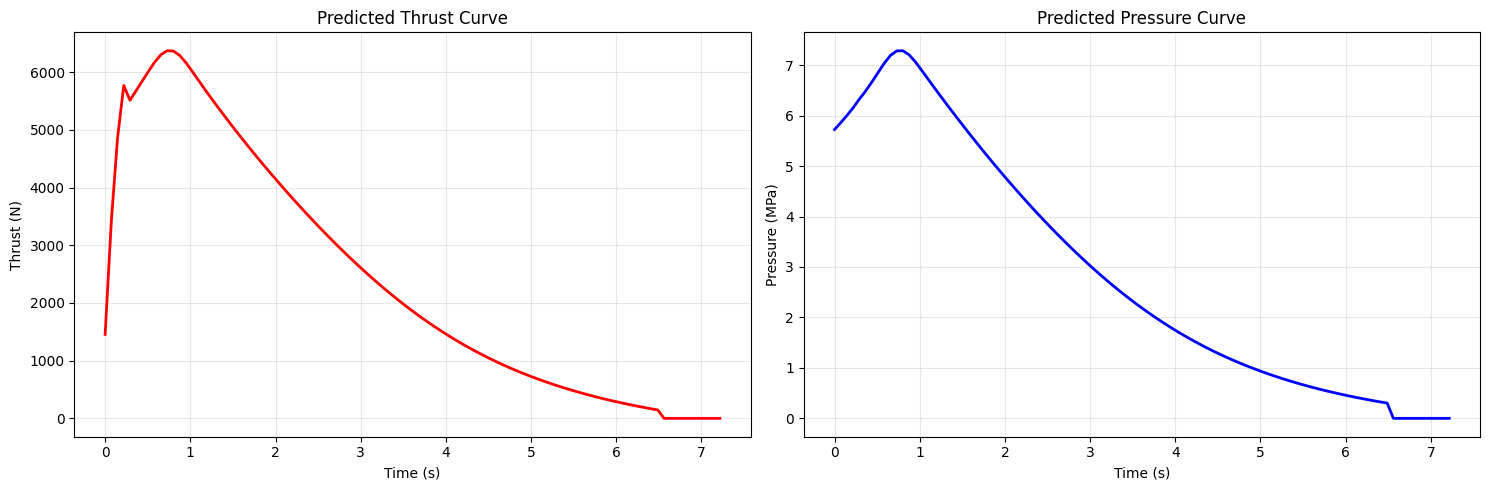

In [11]:
import pandas as pd
import numpy as np
import joblib
import tensorflow as tf
import os
from scipy.signal import savgol_filter
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d
from scipy.integrate import trapezoid

MODEL_PATH = r"M:\\Graduation Project\\Team B\\Code_project\\test models\\Forward Models\\Conical Models\\Conical_Forward_Model.keras"

SCALAR_SCALER_PATH = r"M:\\Graduation Project\\Team B\\Code_project\\test models\\Forward Models\\Conical Models\\con_fwd_scaler_scalars.pkl"

Value_SCALER_PATH = r"M:\\Graduation Project\\Team B\\Code_project\\test models\\Forward Models\\Conical Models\\con_fwd_max_values.pkl"

SCALAR_X_PATH  = r"M:\\Graduation Project\\Team B\\Code_project\\test models\\Forward Models\\Conical Models\\con_fwd_scaler_X.pkl"

s_X = joblib.load(SCALAR_X_PATH)
s_ys = joblib.load(SCALAR_SCALER_PATH)
conical_forward = tf.keras.models.load_model(MODEL_PATH)

# ===================================================================
# Prediction Function for Conical Forward Model (Clean Curve)
# ===================================================================
def get_user_input_and_predict_conical():
    print('\n' + '='*55)
    print('   Moon Grain - Performance Predictor (ReLU Edition)')
    print('='*55)
    try:
        l_val  = float(input('Length (cm):               '))
        od_val = float(input('Diameter (cm):       '))
        id_val = float(input('Forward_Core_Diameter (cm):  '))
        co_val = float(input('Aft_Core_Diameter (cm):          ')) 
        td_val = float(input('Throat Diameter (cm):      '))
        ed_val = float(input('Exit Diameter (cm):        '))

        user_inputs        = np.array([[l_val, od_val, id_val, co_val, td_val, ed_val]])
        user_inputs_scaled = s_X.transform(user_inputs)

        preds = conical_forward.predict(user_inputs_scaled, verbose=0)

        max_vals = joblib.load(Value_SCALER_PATH)
        yt_max = max_vals['yt_max']
        yp_max = max_vals['yp_max']

        # استخراج المنحنيات
        thrust_pred   = preds[0][0] * yt_max
        pressure_pred = preds[1][0] * yp_max
        
        # استخراج القيم الثابتة
        scalars_pred  = s_ys.inverse_transform(preds[2])[0]
        isp           = max(scalars_pred[0], 1e-9)
        burn_time     = max(scalars_pred[2], 1e-9)
        max_thrust_sc = max(scalars_pred[3], 1e-9)

        time_steps = np.linspace(0, burn_time, 100)

        # تنعيم خفيف للمنحنى بدون التأثير على القمة
        smoothed_thrust   = np.clip(savgol_filter(thrust_pred, window_length=7, polyorder=2), 0, None)
        smoothed_pressure = np.clip(savgol_filter(pressure_pred, window_length=7, polyorder=2), 0, None)

        # إغلاق ذيل المنحنى
        peak_idx = np.argmax(smoothed_thrust)
        tail     = smoothed_thrust[peak_idx:]
        cutoff   = np.argmax(tail < 0.02 * smoothed_thrust.max())
        if cutoff > 0:
            smoothed_thrust[peak_idx + cutoff:] = 0
            smoothed_pressure[peak_idx + cutoff:] = 0

        # حساب المساحة من المنحنى النهائي
        calculated_impulse = np.trapezoid(smoothed_thrust, time_steps)
        final_max_thrust = np.max(smoothed_thrust)

        print('\n' + '-'*45)
        print('   Predicted Performance (Conical Grain)')
        print('-'*45)
        print(f'  ISP                   : {isp:.2f} s')
        print(f'  Burn Time             : {burn_time:.2f} s')
        print(f'  Total Impulse         : {calculated_impulse:.2f} N.s')
        print(f'  Max Thrust            : {final_max_thrust:.2f} N')
        print('-'*45)

        fig, axes = plt.subplots(1, 2, figsize=(15, 5))

        axes[0].plot(time_steps, smoothed_thrust, color='red', linewidth=2)
        axes[0].set_title('Predicted Thrust Curve')
        axes[0].set_xlabel('Time (s)'); axes[0].set_ylabel('Thrust (N)')
        axes[0].grid(True, alpha=0.3)

        axes[1].plot(time_steps, smoothed_pressure, color='blue', linewidth=2)
        axes[1].set_title('Predicted Pressure Curve')
        axes[1].set_xlabel('Time (s)'); axes[1].set_ylabel('Pressure (MPa)')
        axes[1].grid(True, alpha=0.3)

        plt.tight_layout()
        plt.show()

    except ValueError:
        print('\n[Error]: Please enter valid numeric values.')
    except Exception as e:
        print(f'\n[Error]: {e}')

get_user_input_and_predict_conical()

# Finocyl Grain Interface

c:\Users\Ctrl-Halim\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\base.py:442: InconsistentVersionWarning: Trying to unpickle estimator RobustScaler from version 1.6.1 when using version 1.7.2. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
c:\Users\Ctrl-Halim\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\base.py:442: InconsistentVersionWarning: Trying to unpickle estimator StandardScaler from version 1.6.1 when using version 1.7.2. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(


✅ predict_finocyl_v3() defined

Example:
  result = predict_finocyl_v3(
      diameter=16, length=50, core_diameter=3,
      num_fins=6, fin_length=1, fin_width=0.6,
      throat_diameter=1.8, exit_diameter=2.7
  )


C:\Users\Ctrl-Halim\AppData\Local\Temp\ipykernel_22532\3805989094.py:75: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  calc_impulse  = float(np.trapz(thrust_curve, time_steps))



   Finocyl Forward V3 — Prediction Results
  Burn Time          : 4.517 s
  ISP                : 174.80 s
  Total Impulse      : 121419.27 N·s
  Impulse (from ∫F dt): 121714.44 N·s
  Max Thrust (scalar): 67847.43 N
  Max Thrust (curve) : 67693.19 N
  Peak Pressure      : 142.093 MPa
  Curve TV (thrust)  : 668.91 ↓smoother<100


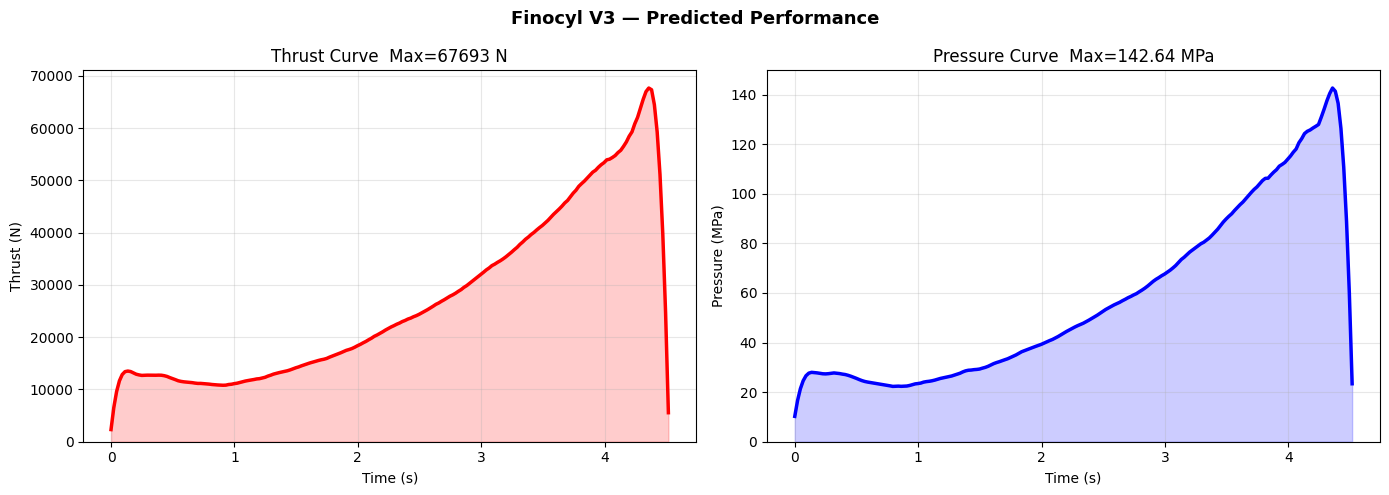

In [15]:
import pandas as pd
import numpy as np
import joblib
import matplotlib.pyplot as plt
import os


from scipy.interpolate import interp1d
from scipy.signal import savgol_filter

import tensorflow as tf

MODEL_PATH = r"M:\\Graduation Project\\Team B\\Code_project\\test models\\Forward Models\\Finocyl Models\\finocyl_forward_v3_final.keras"

params_SCALER_PATH = r"M:\\Graduation Project\\Team B\\Code_project\\test models\\Forward Models\\Finocyl Models\\fin_v3_norm_params.pkl"

ys_SCALER_PATH = r"M:\\Graduation Project\\Team B\\Code_project\\test models\\Forward Models\\Finocyl Models\\fin_v3_scaler_ys.pkl"

SCALAR_X_PATH  = r"M:\\Graduation Project\\Team B\\Code_project\\test models\\Forward Models\\Finocyl Models\\fin_v3_scaler_X.pkl"

s_X = joblib.load(SCALAR_X_PATH)
s_ys = joblib.load(ys_SCALER_PATH)
finocyl_forward = tf.keras.models.load_model(MODEL_PATH, compile=False)
N_POINTS     = 200

# ===================================================================
# Prediction Function V3
# ===================================================================
def predict_finocyl_v3(
    diameter, length, core_diameter,
    num_fins, fin_length, fin_width,
    throat_diameter, exit_diameter,
    plot=True, smooth_output=True
):
    """
    التنبؤ بأداء محرك Finocyl — V3

    Parameters
    ----------
    diameter, length, core_diameter : أبعاد الجسم والقلب (cm)
    num_fins, fin_length, fin_width : عدد الزعانف وأبعادها
    throat_diameter, exit_diameter  : أبعاد الفوهة (cm)
    smooth_output : bool — تنعيم إضافي خفيف على الـ output
                   (للعرض فقط، لا يؤثر على الـ scalars)
    """
    norm_params = joblib.load(params_SCALER_PATH)
    T_MAX = norm_params['thrust_max']
    P_MAX = norm_params['pres_max']

    inp_arr    = np.array([[diameter, length, core_diameter, num_fins,
                             fin_length, fin_width, throat_diameter, exit_diameter]],
                           dtype=np.float32)
    inp_scaled = s_X.transform(inp_arr)

    preds = finocyl_forward.predict(inp_scaled, verbose=0)

    thrust_curve   = np.clip(preds[0][0] * T_MAX, 0, None)
    pressure_curve = np.clip(preds[1][0] * P_MAX, 0, None)

    # Optional light post-smoothing للعرض (لا يغير القيم المتوقعة)
    if smooth_output:
        thrust_curve   = np.clip(savgol_filter(thrust_curve,   window_length=11, polyorder=3), 0, None)
        pressure_curve = np.clip(savgol_filter(pressure_curve, window_length=11, polyorder=3), 0, None)

    sc_log    = s_ys.inverse_transform(preds[2])
    sc_vals   = np.expm1(sc_log)[0]

    burn_time     = max(float(sc_vals[0]), 0.1)
    isp           = max(float(sc_vals[1]), 1.0)
    total_impulse = max(float(sc_vals[2]), 1.0)
    max_thrust_sc = max(float(sc_vals[3]), 1.0)
    peak_pres     = max(float(sc_vals[4]), 0.01)

    time_steps    = np.linspace(0, burn_time, N_POINTS)
    calc_impulse  = float(np.trapz(thrust_curve, time_steps))

    print('\n' + '=' * 58)
    print('   Finocyl Forward V3 — Prediction Results')
    print('=' * 58)
    print(f'  Burn Time          : {burn_time:.3f} s')
    print(f'  ISP                : {isp:.2f} s')
    print(f'  Total Impulse      : {total_impulse:.2f} N·s')
    print(f'  Impulse (from ∫F dt): {calc_impulse:.2f} N·s')
    print(f'  Max Thrust (scalar): {max_thrust_sc:.2f} N')
    print(f'  Max Thrust (curve) : {float(thrust_curve.max()):.2f} N')
    print(f'  Peak Pressure      : {peak_pres:.3f} MPa')
    print(f'  Curve TV (thrust)  : {float(np.mean(np.abs(np.diff(thrust_curve)))):.2f} ↓smoother<100')
    print('=' * 58)

    if plot:
        fig, axes = plt.subplots(1, 2, figsize=(14, 5))
        fig.suptitle('Finocyl V3 — Predicted Performance', fontsize=13, fontweight='bold')

        axes[0].fill_between(time_steps, thrust_curve, alpha=0.2, color='red')
        axes[0].plot(time_steps, thrust_curve, 'r-', lw=2.5)
        axes[0].set_title(f'Thrust Curve  Max={thrust_curve.max():.0f} N')
        axes[0].set_xlabel('Time (s)'); axes[0].set_ylabel('Thrust (N)')
        axes[0].set_ylim(bottom=0); axes[0].grid(True, alpha=0.3)

        axes[1].fill_between(time_steps, pressure_curve, alpha=0.2, color='blue')
        axes[1].plot(time_steps, pressure_curve, 'b-', lw=2.5)
        axes[1].set_title(f'Pressure Curve  Max={pressure_curve.max():.2f} MPa')
        axes[1].set_xlabel('Time (s)'); axes[1].set_ylabel('Pressure (MPa)')
        axes[1].set_ylim(bottom=0); axes[1].grid(True, alpha=0.3)

        plt.tight_layout()
        plt.show()

    return {
        'thrust_curve'   : thrust_curve,
        'pressure_curve' : pressure_curve,
        'time_steps'     : time_steps,
        'burn_time'      : burn_time,
        'isp'            : isp,
        'total_impulse'  : total_impulse,
        'max_thrust'     : float(thrust_curve.max()),
        'peak_pressure'  : float(pressure_curve.max()),
    }

print('✅ predict_finocyl_v3() defined')
print('\nExample:')
print('  result = predict_finocyl_v3(')
print('      diameter=16, length=50, core_diameter=3,')
print('      num_fins=6, fin_length=1, fin_width=0.6,')
print('      throat_diameter=1.8, exit_diameter=2.7')
print('  )')
result = predict_finocyl_v3(
      diameter=20, length=130, core_diameter=3,
      num_fins=8, fin_length=1, fin_width=0.2,
      throat_diameter=2.2, exit_diameter= 3.3
  )